# Experiment 11: Calibrating lr_v/lr_b — relative error vs. learning rate only (single-objective)

Runs Optuna CMA-ES (single-objective: `wh_loss + sv_loss`, searching `lr_v`/`lr_b` via
`DEFAULT_PARAM_SPACE`) **twice** on the same simulated recording used in
`sim_04`/`sim_09`/`sim_10`, once under each update rule compared (at fixed lr values) in
`sim_10` -- but here the learning rates are *calibrated* by Optuna instead of fixed at
the old recommendation, so each update rule gets its own best-fit `lr_v`/`lr_b`.

**Configuration summary**
- `wh_mode = 'kl_to_cal'`
- `max_iter_b = 5`
- `wh_b_coupling = False` (disabled)

**Conditions compared**
| Condition | `lr_alone` | Update rule |
|---|---|---|
| No adaptation | — | — |
| Relative error | `False` | step ∝ `lr_{v,b}` × direction-normalized gradient × signed error `e_v`/`e_b` |
| Learning rate only | `True` | step ∝ `lr_{v,b}` × direction-normalized gradient (constant every batch, no error term) |

Each condition gets its own independent CMA-ES search (50 trials) over `lr_v`/`lr_b` --
the optimal rate for a constant unconditional step is not expected to match the optimal
rate when the step also scales with the signed calibration error, so calibrating them
separately (rather than reusing one search's result for both) is the fair comparison.


In [ ]:
import sys
sys.path.insert(0, '../../..')

import json
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from matplotlib.patches import Rectangle

from adapt_decomp.loaders import load_example
from adapt_decomp.adaptation import AdaptDecomp
from adapt_decomp.config import Config
from adapt_decomp.optimize import optimize_adapt_decomp, DEFAULT_PARAM_SPACE
from adapt_decomp.utils import (
    rate_of_agreement_paired, rate_of_agreement,
    get_coefficient_of_variation, get_discharge_rate,
    get_pulse_to_noise_ratio, get_silhouette_measure,
    find_reliable_units,
)

%load_ext autoreload
%autoreload 2

sns.set_theme(style='whitegrid', font_scale=1.1)


In [ ]:
# ── Run control ──────────────────────────────────────────────────────────────
# Set RUN_OPTIMISATION = False to reload saved results without re-running Optuna.
RUN_OPTIMISATION = True

EXP_NAME    = 'sim_09_multiarm_kl_to_cal_no_coupling_iterb5_lr_alone_calibration_cmaes'
RESULTS_DIR = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'opt_results', EXP_NAME)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

def _to_json_safe(v):
    if isinstance(v, torch.Tensor): return v.item()
    if hasattr(v, 'item'): return v.item()
    return v


## 1. Load data

In [ ]:
path_emg    = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'data_sim.hdf5')
path_decomp = Path('..', '..', '..', 'data', 'JNE_data', 'sim', 'decomp_sim.mat')

data = load_example(path_emg, path_decomp, False)

n_units      = data['sep_vectors'].shape[0]
fs           = data['fs']
timestamps   = data['timestamps'].numpy()
ext_fact     = data['ext_fact']
n_samples    = data['emg'].shape[0]
duration_s   = n_samples / fs

print(f'Units: {n_units}  |  Samples: {n_samples}  |  fs: {fs} Hz  |  Duration: {duration_s:.1f} s')


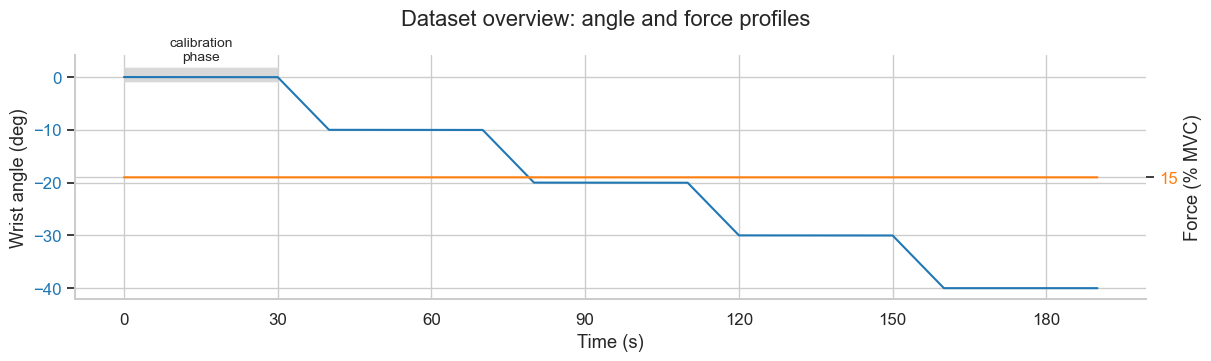

In [4]:
fig, ax = plt.subplots(figsize=(12, 3.5), layout='constrained')
ax.add_patch(Rectangle((0, -1), 30, 3, facecolor='grey', alpha=0.3))
ax.text(15, 5, 'calibration\nphase', dict(ha='center', va='center', fontsize=10))
ax.plot(data['timestamps'], data['angle_profile'], color='tab:blue')
ax.set(ylabel='Wrist angle (deg)', xlabel='Time (s)')
ax.tick_params(axis='y', labelcolor='tab:blue')
ax1 = ax.twinx()
ax1.plot(data['timestamps'], data['force_profile'], color='tab:orange')
ax1.set(ylabel='Force (% MVC)', yticks=[15])
ax1.tick_params(axis='y', labelcolor='tab:orange')
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
    ax1.spines[spine].set_visible(False)
ax1.set(xticks=range(0, int(duration_s) + 1, 30))
plt.suptitle('Dataset overview: angle and force profiles')
plt.show()


## 2. No-adaptation baseline

All adaptation flags off. The calibration V and B are applied unchanged.

In [5]:
_out_no_path = RESULTS_DIR / 'out_no.pt'

if RUN_OPTIMISATION:
    cfg_no = Config()
    cfg_no.ext_fact       = data['ext_fact']
    cfg_no.adapt_wh       = False
    cfg_no.adapt_sv       = False
    cfg_no.adapt_sd       = False
    cfg_no.log_loss       = True
    cfg_no.device         = 'cpu'
    cfg_no.wh_mode        = 'kl_to_cal'
    cfg_no.contrast_scope = 'spike_based'
    cfg_no.wh_b_coupling  = False

    dec_no = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_no,
    )
    out_no = dec_no.run()
    torch.save(out_no, _out_no_path)
    print(f'Saved → {_out_no_path}')
else:
    out_no = torch.load(_out_no_path, weights_only=False)
    print(f'Loaded from {_out_no_path}')
print('No-adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration\out_no.pt
No-adaptation run complete.


## 3. Single-objective calibration — relative error (`lr_alone=False`)

Optuna CMA-ES minimises `wh_loss + sv_loss` over `lr_v`/`lr_b` (see `DEFAULT_PARAM_SPACE`)
under the default update rule: the direction-normalized natural gradient is scaled by
`lr_{v,b}` **and** the signed calibration error `e_v`/`e_b`.


In [6]:
# Search space shared by both calibration runs
param_space = DEFAULT_PARAM_SPACE   # lr_v, lr_b

base_config_re = {
    'ext_fact':       data['ext_fact'],
    'adapt_wh':       True,
    'adapt_sv':       True,
    'adapt_sd':       True,
    'wh_mode':        'kl_to_cal',
    'contrast_scope': 'spike_based',
    'wh_b_coupling':  False,
    'max_iter_b':     5,
    'log_loss':       True,
    'device':         'cpu',
    'trace_check':    True,
    'lr_alone':       False,
}


In [7]:
_cfg_re_path   = RESULTS_DIR / 'best_config_re.json'
_study_re_path = RESULTS_DIR / 'study_re_trials.csv'

if RUN_OPTIMISATION:
    best_config_re, study_re = optimize_adapt_decomp(
        emg             = data['emg'],
        whitening       = data['whitening'],
        sep_vectors     = data['sep_vectors'],
        base_centroids  = data['base_centroids'],
        spike_centroids = data['spike_centroids'],
        emg_calib       = data['emg_calib'],
        ipts_calib      = data['ipts_calib'],
        spikes_calib    = data['spikes_calib'],
        param_space     = param_space,
        base_config     = base_config_re,
        n_trials        = 50,
        preprocess      = data['preprocess'],
    )
    with open(_cfg_re_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_re.items()}, f, indent=2)
    pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                  for t in study_re.trials if t.value is not None]).to_csv(_study_re_path, index=False)
    print(f'Saved → {_cfg_re_path}')
else:
    with open(_cfg_re_path) as f:
        best_config_re = json.load(f)
    study_re = None
    print(f'Loaded from {_cfg_re_path}')

print('Best hyperparameters (relative error):')
for k in param_space:
    print(f'  {k}: {best_config_re[k]:.4e}')


Saved → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration\best_config_re.json
Best hyperparameters (relative error):
  lr_v: 1.7566e-03
  lr_b: 6.3128e-03


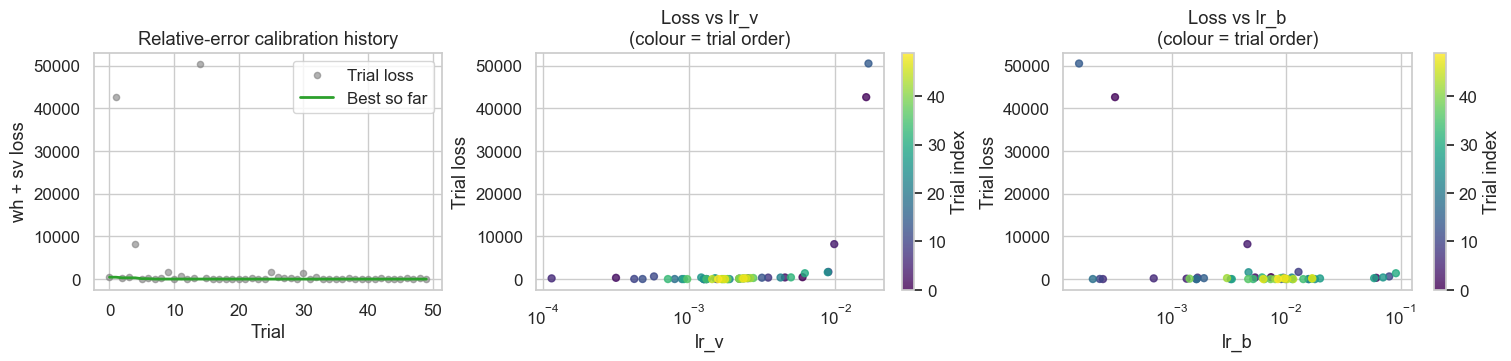

In [8]:
if study_re is None:
    print('Optimisation history not available (loaded from file).')
else:
    values      = [t.value for t in study_re.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(values)

    log_params    = [k for k, v in param_space.items() if v[0] == 'log_float']
    linear_params = [k for k, v in param_space.items() if v[0] != 'log_float']
    n_panels = 1 + len(log_params) + len(linear_params)
    fig, axs = plt.subplots(1, n_panels, figsize=(5 * n_panels, 3.5), layout='constrained')

    axs[0].scatter(range(len(values)), values, s=20, alpha=0.6, color='tab:grey', label='Trial loss')
    axs[0].plot(range(len(values)), best_so_far, color='tab:green', linewidth=2, label='Best so far')
    axs[0].set(xlabel='Trial', ylabel='wh + sv loss',
               title='Relative-error calibration history')
    axs[0].legend()

    for ax, name in zip(axs[1:], log_params + linear_params):
        is_log = param_space[name][0] == 'log_float'
        vals = [t.params[name] for t in study_re.trials if name in t.params and t.value is not None]
        cols = [t.value        for t in study_re.trials if name in t.params and t.value is not None]
        sc = ax.scatter(vals, cols, c=range(len(vals)), cmap='viridis', s=25, alpha=0.8)
        if is_log:
            ax.set_xscale('log')
        ax.set(xlabel=name, ylabel='Trial loss',
               title=f'Loss vs {name}\n(colour = trial order)')
        plt.colorbar(sc, ax=ax, label='Trial index')

    plt.show()


Apply the best relative-error config and run the full decomposition.

In [9]:
_out_re_path = RESULTS_DIR / 'out_re.pt'

if RUN_OPTIMISATION:
    cfg_re = Config()
    for k, v in best_config_re.items():
        setattr(cfg_re, k, v)
    cfg_re.debug = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics

    dec_re = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_re,
    )
    out_re = dec_re.run()
    torch.save(out_re, _out_re_path)
    print(f'Saved → {_out_re_path}')
else:
    out_re = torch.load(_out_re_path, weights_only=False)
    print(f'Loaded from {_out_re_path}')
print('Relative-error adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration\out_re.pt
Relative-error adaptation run complete.


## 4. Single-objective calibration — learning rate only (`lr_alone=True`)

Same Optuna CMA-ES search over `lr_v`/`lr_b`, but with the signed error `e_v`/`e_b`
dropped: `lr_{v,b}` alone sets a constant, direction-normalized step applied every batch
regardless of how close the model already is to calibration (see `Config.lr_alone`'s
docstring). Calibrated independently from the relative-error run above.


In [10]:
base_config_lo = {**base_config_re, 'lr_alone': True}


In [11]:
_cfg_lo_path   = RESULTS_DIR / 'best_config_lo.json'
_study_lo_path = RESULTS_DIR / 'study_lo_trials.csv'

if RUN_OPTIMISATION:
    best_config_lo, study_lo = optimize_adapt_decomp(
        emg             = data['emg'],
        whitening       = data['whitening'],
        sep_vectors     = data['sep_vectors'],
        base_centroids  = data['base_centroids'],
        spike_centroids = data['spike_centroids'],
        emg_calib       = data['emg_calib'],
        ipts_calib      = data['ipts_calib'],
        spikes_calib    = data['spikes_calib'],
        param_space     = param_space,
        base_config     = base_config_lo,
        n_trials        = 50,
        preprocess      = data['preprocess'],
    )
    with open(_cfg_lo_path, 'w') as f:
        json.dump({k: _to_json_safe(v) for k, v in best_config_lo.items()}, f, indent=2)
    pd.DataFrame([{'trial': t.number, 'value': t.value, **t.params}
                  for t in study_lo.trials if t.value is not None]).to_csv(_study_lo_path, index=False)
    print(f'Saved → {_cfg_lo_path}')
else:
    with open(_cfg_lo_path) as f:
        best_config_lo = json.load(f)
    study_lo = None
    print(f'Loaded from {_cfg_lo_path}')

print('Best hyperparameters (learning rate only):')
for k in param_space:
    print(f'  {k}: {best_config_lo[k]:.4e}')


Saved → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration\best_config_lo.json
Best hyperparameters (learning rate only):
  lr_v: 3.6394e-03
  lr_b: 3.8877e-03


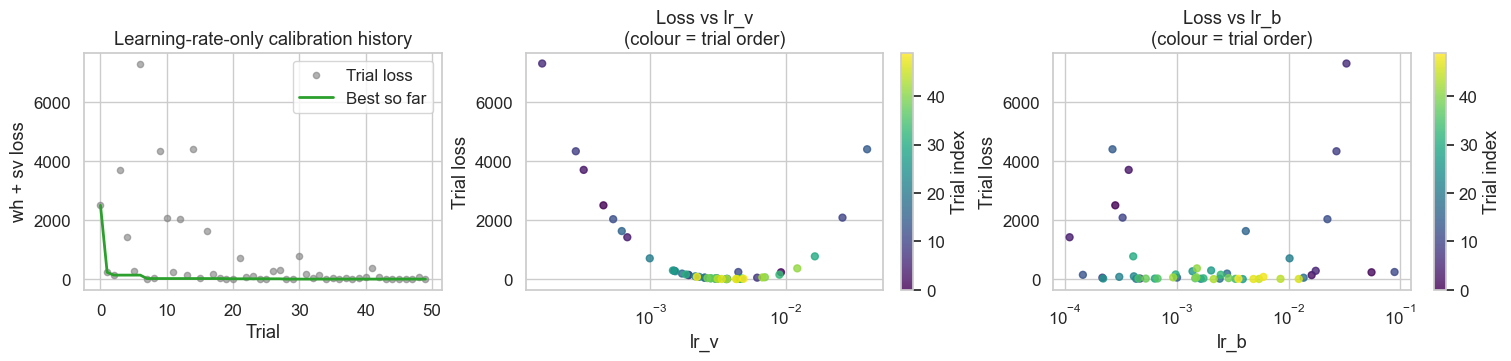

In [12]:
if study_lo is None:
    print('Optimisation history not available (loaded from file).')
else:
    values      = [t.value for t in study_lo.trials if t.value is not None]
    best_so_far = np.minimum.accumulate(values)

    log_params    = [k for k, v in param_space.items() if v[0] == 'log_float']
    linear_params = [k for k, v in param_space.items() if v[0] != 'log_float']
    n_panels = 1 + len(log_params) + len(linear_params)
    fig, axs = plt.subplots(1, n_panels, figsize=(5 * n_panels, 3.5), layout='constrained')

    axs[0].scatter(range(len(values)), values, s=20, alpha=0.6, color='tab:grey', label='Trial loss')
    axs[0].plot(range(len(values)), best_so_far, color='tab:green', linewidth=2, label='Best so far')
    axs[0].set(xlabel='Trial', ylabel='wh + sv loss',
               title='Learning-rate-only calibration history')
    axs[0].legend()

    for ax, name in zip(axs[1:], log_params + linear_params):
        is_log = param_space[name][0] == 'log_float'
        vals = [t.params[name] for t in study_lo.trials if name in t.params and t.value is not None]
        cols = [t.value        for t in study_lo.trials if name in t.params and t.value is not None]
        sc = ax.scatter(vals, cols, c=range(len(vals)), cmap='viridis', s=25, alpha=0.8)
        if is_log:
            ax.set_xscale('log')
        ax.set(xlabel=name, ylabel='Trial loss',
               title=f'Loss vs {name}\n(colour = trial order)')
        plt.colorbar(sc, ax=ax, label='Trial index')

    plt.show()


Apply the best learning-rate-only config and run the full decomposition.

In [13]:
_out_lo_path = RESULTS_DIR / 'out_lo.pt'

if RUN_OPTIMISATION:
    cfg_lo = Config()
    for k, v in best_config_lo.items():
        setattr(cfg_lo, k, v)
    cfg_lo.debug = True   # records per-batch delta_{V,B}_{raw_,}norm for §7 clip diagnostics

    dec_lo = AdaptDecomp(
        emg             = data['emg'].clone(),
        whitening       = data['whitening'].clone(),
        sep_vectors     = data['sep_vectors'].clone(),
        base_centroids  = data['base_centroids'].clone(),
        spike_centroids = data['spike_centroids'].clone(),
        emg_calib       = data['emg_calib'].clone(),
        ipts_calib      = data['ipts_calib'].clone(),
        spikes_calib    = data['spikes_calib'].clone(),
        preprocess      = data['preprocess'],
        config          = cfg_lo,
    )
    out_lo = dec_lo.run()
    torch.save(out_lo, _out_lo_path)
    print(f'Saved → {_out_lo_path}')
else:
    out_lo = torch.load(_out_lo_path, weights_only=False)
    print(f'Loaded from {_out_lo_path}')
print('Learning-rate-only adaptation run complete.')


Saved → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration\out_lo.pt
Learning-rate-only adaptation run complete.


## 5. Execution time per batch

In [14]:
cond_labels  = ['No adaptation', 'Relative error', 'Learning rate only']
cond_colors  = {
    'No adaptation':      'tab:orange',
    'Relative error':     'tab:blue',
    'Learning rate only': 'tab:green',
}
cond_outputs = {
    'No adaptation':      out_no,
    'Relative error':     out_re,
    'Learning rate only': out_lo,
}


In [15]:
for label in cond_labels:
    out = cond_outputs[label]
    print(label)
    print('-' * len(label))
    for key in ['wh_time_ms', 'sv_time_ms', 'sd_time_ms', 'total_time_ms']:
        print(f'  {key:>15}: {out[key].mean():.3f} ± {out[key].std():.3f} ms')
    print()


No adaptation
-------------
       wh_time_ms: 20.236 ± 22.935 ms
       sv_time_ms: 0.142 ± 0.614 ms
       sd_time_ms: 0.619 ± 1.085 ms
    total_time_ms: 20.997 ± 22.978 ms

Relative error
--------------
       wh_time_ms: 15.362 ± 6.029 ms
       sv_time_ms: 3.918 ± 3.730 ms
       sd_time_ms: 0.460 ± 1.170 ms
    total_time_ms: 19.741 ± 6.383 ms

Learning rate only
------------------
       wh_time_ms: 20.817 ± 21.682 ms
       sv_time_ms: 5.513 ± 3.154 ms
       sd_time_ms: 0.668 ± 0.940 ms
    total_time_ms: 26.998 ± 22.583 ms



## 6. Loss trajectories

- **wh_loss**: KL divergence between online and calibration whitened covariance
- **sv_loss**: squared contrast error per source
- **centroid_loss**: squared centroid deviation per source (logged for monitoring)

Values near zero mean the online statistics match calibration.


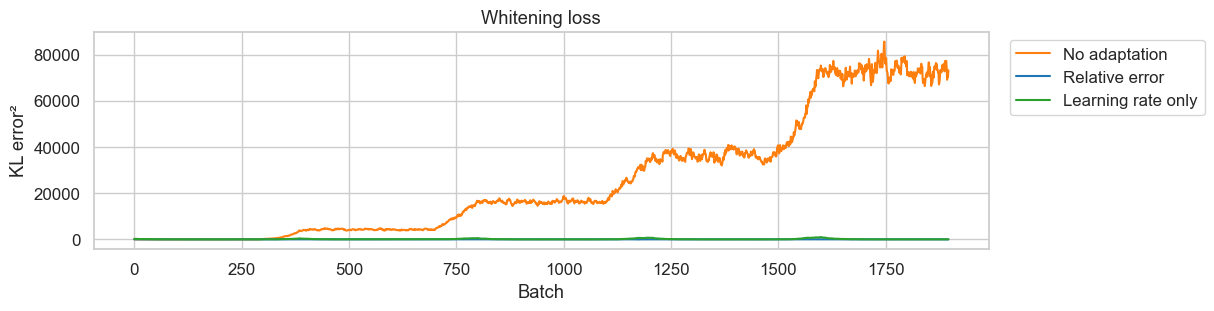

In [16]:
# Whitening loss
fig, ax = plt.subplots(figsize=(12, 3), layout='constrained')
for label in cond_labels:
    ax.plot(cond_outputs[label]['wh_loss'][10:-1], label=label, color=cond_colors[label])
ax.set(xlabel='Batch', ylabel='KL error²', title='Whitening loss')
ax.legend(loc='upper right', bbox_to_anchor=(1.25, 1))
plt.show()


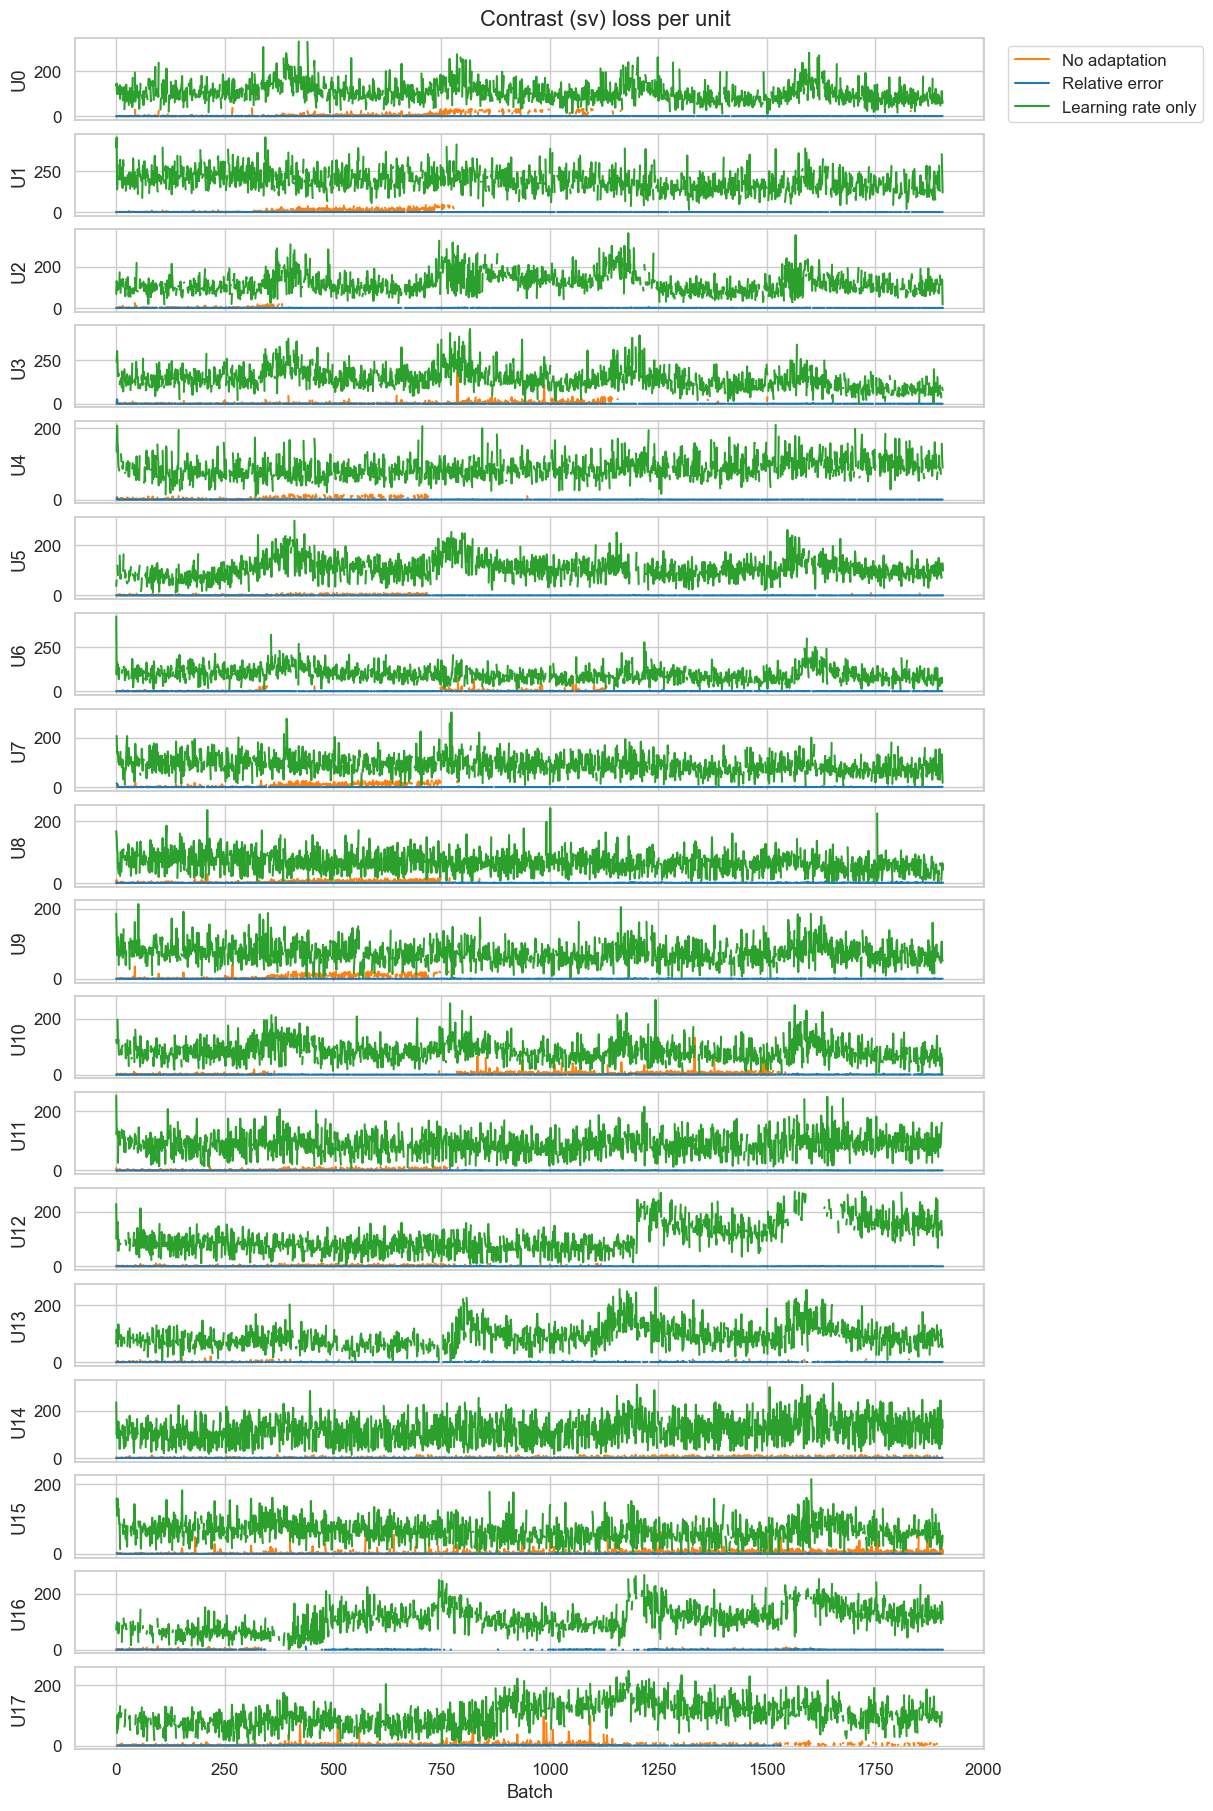

In [17]:
# Contrast (sv) loss per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        axs[u].plot(cond_outputs[label]['sv_loss'][:, u], label=label, color=cond_colors[label])
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('Contrast (sv) loss per unit')
plt.show()


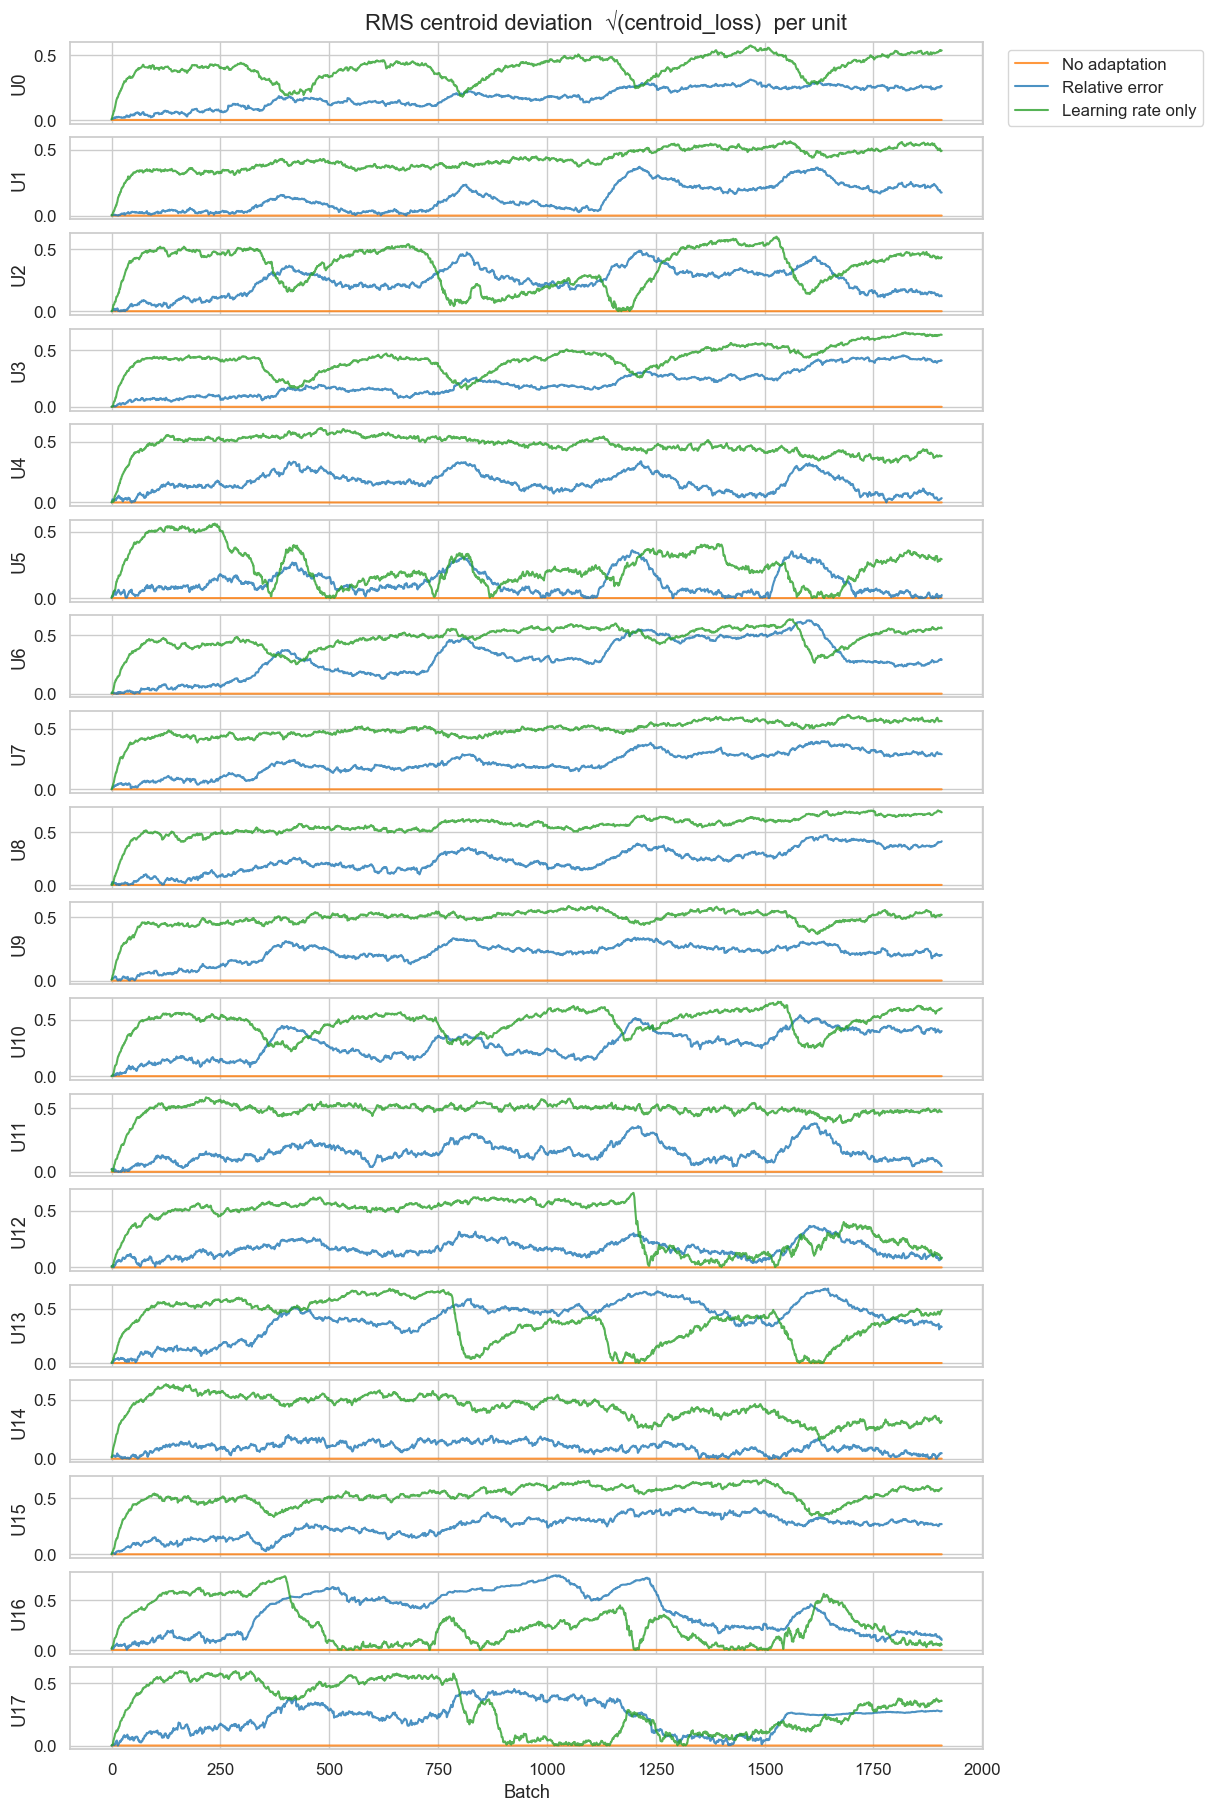

In [18]:
# RMS centroid deviation per unit
fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out = cond_outputs[label]
        if 'centroid_loss' in out:
            axs[u].plot(
                np.sqrt(out['centroid_loss'][:, u].numpy()),
                label=label, color=cond_colors[label], alpha=0.8,
            )
    axs[u].set(ylabel=f'U{u}')
    if u == 0:
        axs[u].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Batch')
plt.suptitle('RMS centroid deviation  √(centroid_loss)  per unit')
plt.show()


## 7. Clipping diagnostics

How often does the safety-net trust-region clip (`safety_clip_multiplier_{v,b} * lr_{v,b}`)
actually engage, versus the direction-normalized step being applied at its full,
unclipped size? Ratio = `‖Δ_applied‖ / ‖Δ_target‖`: 1.0 means the natural-gradient step
went through unchanged; below 1.0 means the clip capped it that batch. Requires
`cfg.debug=True` (set in the Relative-error / Learning-rate-only config cells above),
which records per-batch `delta_{V,B}_{raw_,}norm`. No-adaptation is excluded -- it never
takes a V/B step, so there's nothing to clip.


In [19]:
def _clip_ratios(diagnostics, n_units, tol=1e-6):
    """Per-batch ratio of applied delta-norm to pre-clip target norm.

    ratio == 1  -> step applied unchanged (clip inactive that batch)
    ratio <  1  -> the safety-net trust-region clip capped the step
    V is scalar (one whitening update per batch); B is per-unit ([n_units]).
    """
    idxs    = sorted(diagnostics.keys())
    v_ratio = np.full(len(idxs), np.nan)
    b_ratio = np.full((len(idxs), n_units), np.nan)
    for row, i in enumerate(idxs):
        d = diagnostics[i]
        if 'delta_V_raw_norm' in d and d['delta_V_raw_norm'] > tol:
            v_ratio[row] = d['delta_V_norm'] / d['delta_V_raw_norm']
        if 'delta_B_raw_norm' in d:
            raw, norm = d['delta_B_raw_norm'].numpy(), d['delta_B_norm'].numpy()
            valid = raw > tol
            b_ratio[row, valid] = norm[valid] / raw[valid]
    return np.array(idxs), v_ratio, b_ratio


clip_conditions = ['Relative error', 'Learning rate only']
clip_diag = {}
for label in clip_conditions:
    batches, v_ratio, b_ratio = _clip_ratios(cond_outputs[label]['diagnostics'], n_units)
    clip_diag[label] = {'batches': batches, 'v_ratio': v_ratio, 'b_ratio': b_ratio}

    v_clipped_pct = np.nanmean(v_ratio < 1 - 1e-6) * 100
    b_clipped_pct = np.nanmean(b_ratio  < 1 - 1e-6) * 100
    print(f'{label:>19}: V clipped in {v_clipped_pct:5.1f}% of batches  |  '
          f'B clipped in {b_clipped_pct:5.1f}% of (batch, unit) pairs')


     Relative error: V clipped in   0.0% of batches  |  B clipped in   0.1% of (batch, unit) pairs
 Learning rate only: V clipped in   0.0% of batches  |  B clipped in  80.9% of (batch, unit) pairs


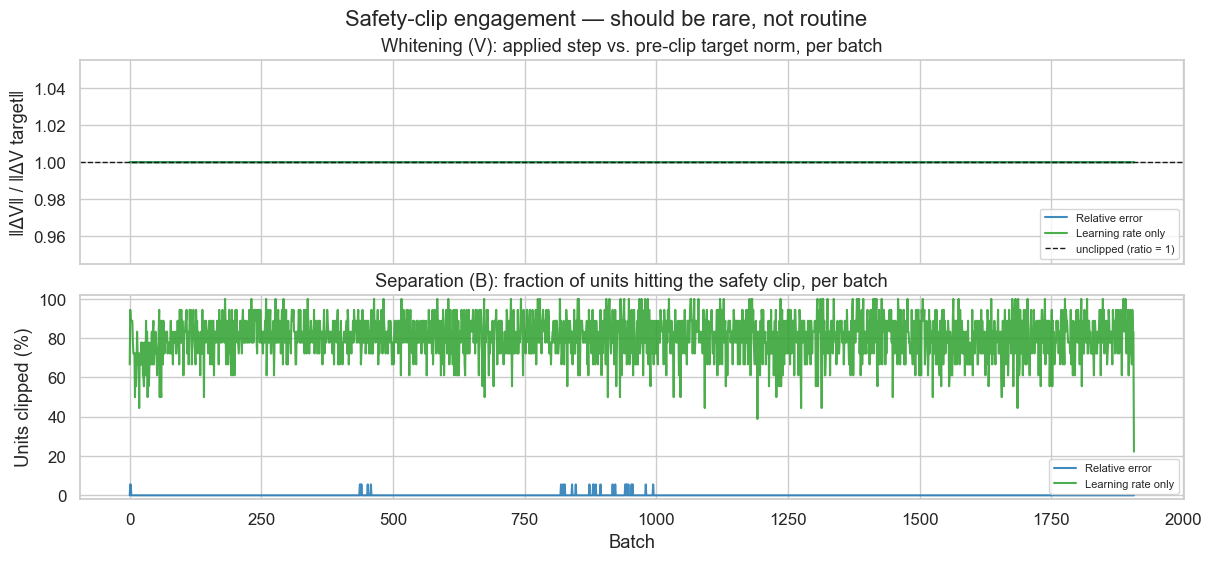

In [20]:
fig, (ax_v, ax_b) = plt.subplots(2, 1, figsize=(12, 5.5), layout='constrained', sharex=True)

for label in clip_conditions:
    cd = clip_diag[label]
    ax_v.plot(cd['batches'], cd['v_ratio'], label=label, color=cond_colors[label], alpha=0.85)
ax_v.axhline(1.0, color='k', linestyle='--', linewidth=1, label='unclipped (ratio = 1)')
ax_v.set(ylabel='‖ΔV‖ / ‖ΔV target‖',
         title='Whitening (V): applied step vs. pre-clip target norm, per batch')
ax_v.legend(fontsize=8, loc='lower right')

for label in clip_conditions:
    cd = clip_diag[label]
    frac_clipped = np.nanmean(cd['b_ratio'] < 1 - 1e-6, axis=1) * 100
    ax_b.plot(cd['batches'], frac_clipped, label=label, color=cond_colors[label], alpha=0.85)
ax_b.set(xlabel='Batch', ylabel='Units clipped (%)', ylim=(-2, 102),
         title='Separation (B): fraction of units hitting the safety clip, per batch')
ax_b.legend(fontsize=8)

plt.suptitle('Safety-clip engagement — should be rare, not routine')
plt.show()


## 8. IPTs and spike trains

Squared IPTs with detected spike times overlaid.

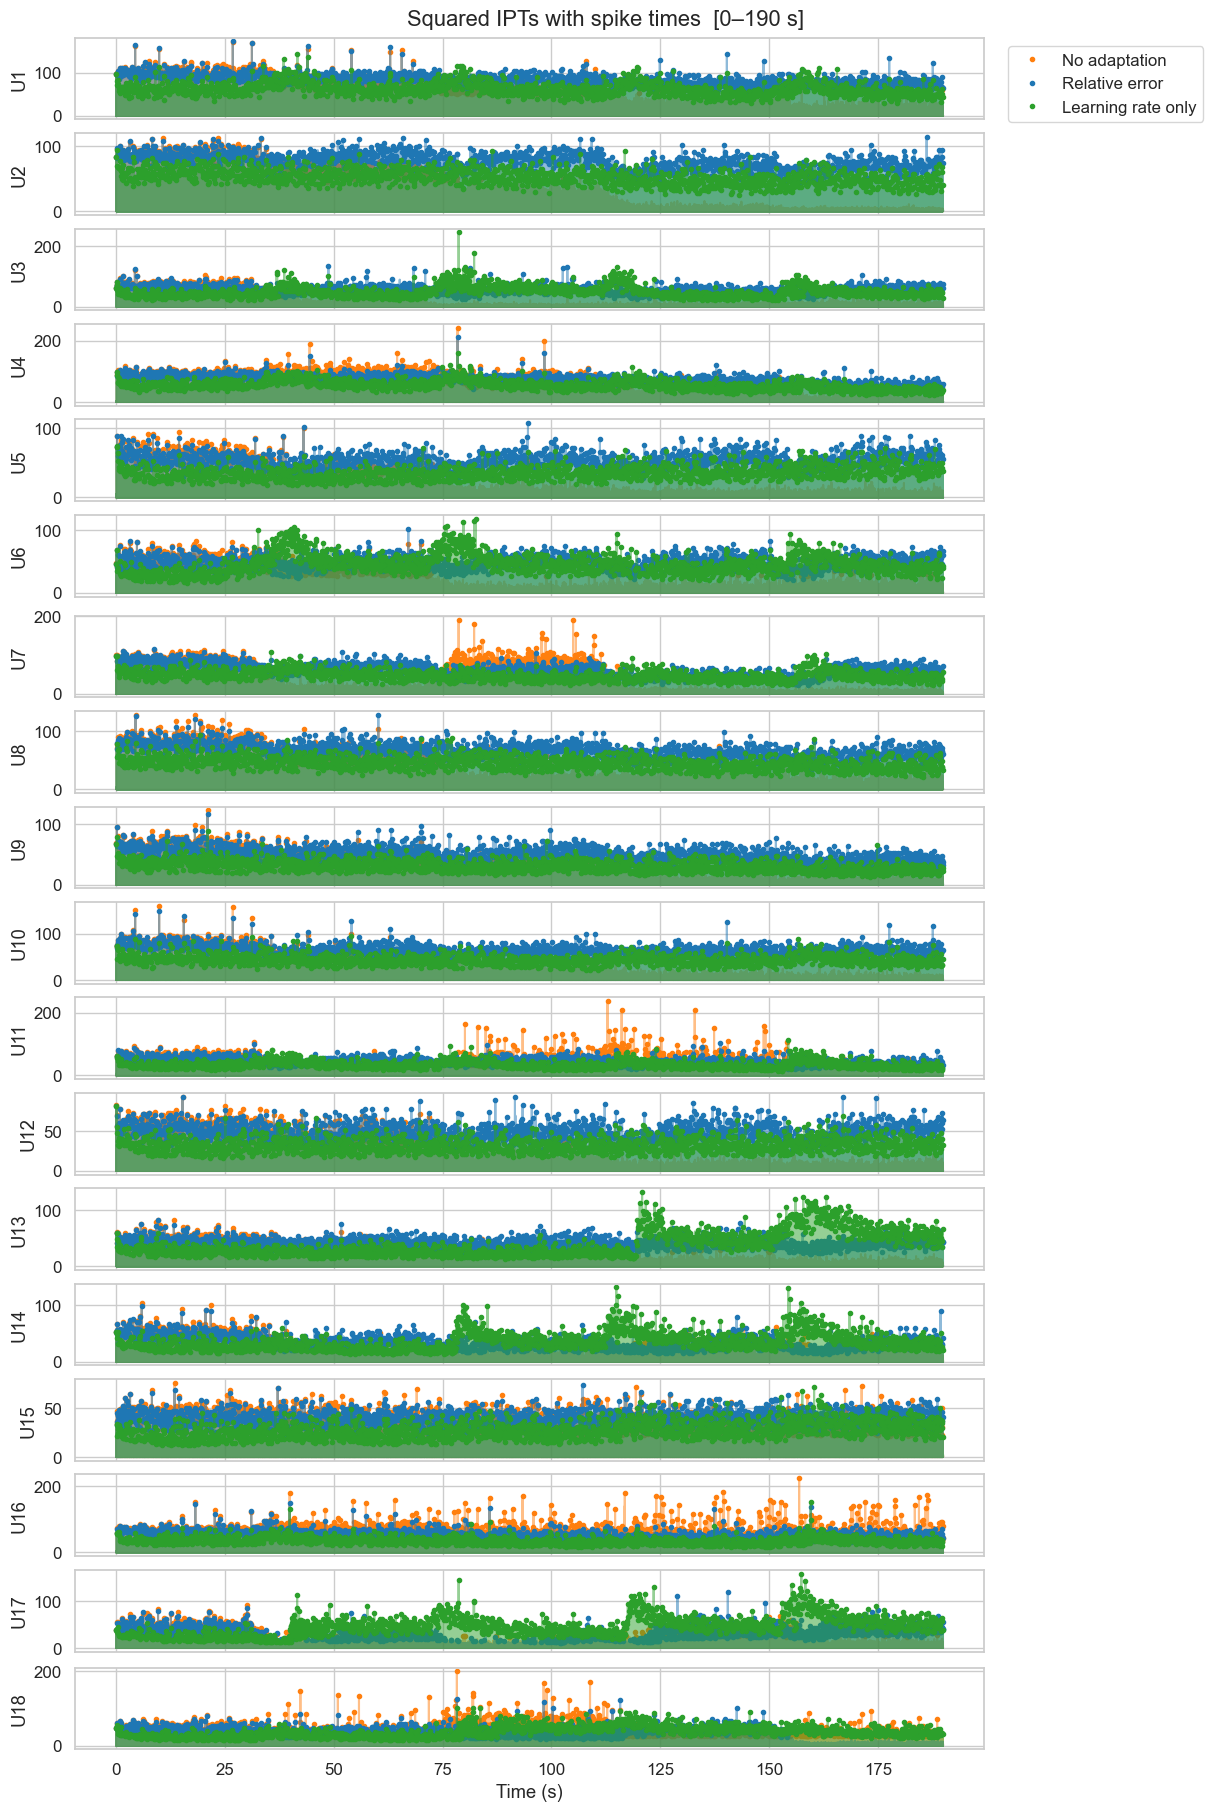

In [21]:
t0, t1 = 0, int(duration_s)
idxs   = np.arange(int(t0 * fs), int(t1 * fs))

fig, axs = plt.subplots(n_units, 1, figsize=(12, n_units), layout='constrained', sharex=True)
for u in range(n_units):
    for label in cond_labels:
        out     = cond_outputs[label]
        ipts_sq = out['ipts'][idxs, u].numpy() ** 2
        axs[u].plot(data['timestamps'][idxs], ipts_sq, color=cond_colors[label], alpha=0.5)
        smask = out['spikes'][idxs, u].to(bool)
        axs[u].plot(
            data['timestamps'][idxs][smask], ipts_sq[smask],
            linestyle='None', marker='.', color=cond_colors[label],
            label=label if u == 0 else None,
        )
    axs[u].set(ylabel=f'U{u + 1}')
axs[0].legend(loc='upper right', bbox_to_anchor=(1.25, 1))
axs[-1].set(xlabel='Time (s)')
plt.suptitle(f'Squared IPTs with spike times  [{t0}–{t1} s]')
plt.show()


## 9. Decomposition quality metrics

A unit is **good** if SIL ≥ 0.9, DR ∈ [5, 35] pps, CoV ≤ 35%, PNR ≥ 30 dB.

In [22]:
rows = []
for label in cond_labels:
    out       = cond_outputs[label]
    spikes_np = out['spikes'].numpy().astype(float)
    ipts_np   = out['ipts'].numpy()

    sil  = get_silhouette_measure(spikes_np, ipts_np, ext_fact)
    pnr  = get_pulse_to_noise_ratio(spikes_np, ipts_np, ext_fact)
    dr   = get_discharge_rate(spikes_np, timestamps, discard_isi=None)
    cov  = get_coefficient_of_variation(spikes_np, timestamps, discard_isi=None)
    good = find_reliable_units(dr, cov, sil, pnr,
                               dr_low_thr=5, dr_upp_thr=35, cov_thr=0.35,
                               sil_thr=0.9, pnr_thr=30)
    for u in range(spikes_np.shape[1]):
        rows.append({'unit': u, 'condition': label, 'good': bool(good[u]),
                     'SIL': sil[u], 'PNR (dB)': pnr[u], 'DR (pps)': dr[u], 'CoV (%)': cov[u]})

df_all  = pd.DataFrame(rows)
n_total = df_all['unit'].nunique()

print(df_all.groupby('condition')[['SIL', 'PNR (dB)', 'DR (pps)', 'CoV (%)']]
      .agg(['median', 'mean']).round(2))
print()
for cond, grp in df_all.groupby('condition'):
    print(f'{cond}: {grp["good"].sum()} / {n_total} good units')


                      SIL       PNR (dB)        DR (pps)       CoV (%)      
                   median  mean   median   mean   median  mean  median  mean
condition                                                                   
Learning rate only   0.91  0.90    31.19  31.01     8.81  8.89    0.33  0.31
No adaptation        0.94  0.93    31.78  32.16     5.41  5.91    3.17  3.21
Relative error       0.96  0.95    35.73  36.01     9.22  9.37    0.22  0.31

Learning rate only: 6 / 18 good units
No adaptation: 0 / 18 good units
Relative error: 15 / 18 good units


C:\Users\Irene\AppData\Local\Temp\ipykernel_5804\3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_5804\3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Irene\AppData\Local\Temp\ipykernel_5804\3505073099.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
C:\Users\Iren

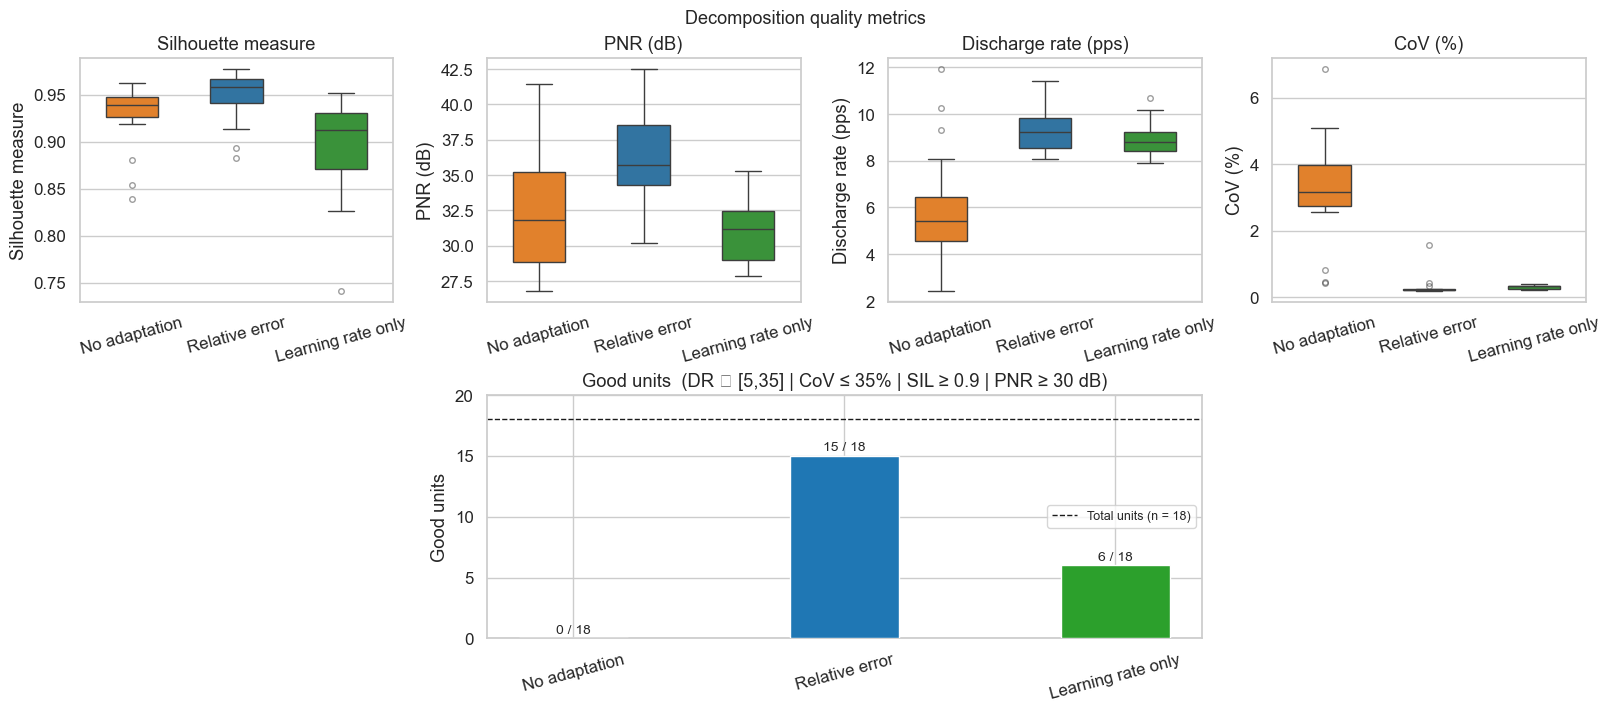

In [23]:
order   = cond_labels
palette = cond_colors

df_all['condition'] = pd.Categorical(df_all['condition'], categories=order, ordered=True)

fig = plt.figure(figsize=(16, 7), layout='constrained')
gs  = fig.add_gridspec(2, 4)
ax_sil = fig.add_subplot(gs[0, 0])
ax_pnr = fig.add_subplot(gs[0, 1])
ax_dr  = fig.add_subplot(gs[0, 2])
ax_cov = fig.add_subplot(gs[0, 3])
ax_bar = fig.add_subplot(gs[1, 1:3])

for ax, col, ylabel in [
    (ax_sil, 'SIL',      'Silhouette measure'),
    (ax_pnr, 'PNR (dB)', 'PNR (dB)'),
    (ax_dr,  'DR (pps)', 'Discharge rate (pps)'),
    (ax_cov, 'CoV (%)',  'CoV (%)'),
]:
    sns.boxplot(data=df_all, x='condition', y=col, order=order, palette=palette,
                width=0.5, flierprops=dict(marker='o', markersize=4, alpha=0.5), ax=ax)
    ax.set(xlabel='', ylabel=ylabel, title=ylabel)
    ax.tick_params(axis='x', rotation=15)

good_counts = df_all.groupby('condition', observed=True)['good'].sum().reindex(order)
bars = ax_bar.bar(order, good_counts.values,
                  color=[palette[c] for c in order], width=0.4, zorder=3)
ax_bar.axhline(n_total, color='k', linestyle='--', linewidth=1,
               label=f'Total units (n = {n_total})')
ax_bar.set(ylabel='Good units', ylim=(0, n_total + 2),
           title='Good units  (DR ∈ [5,35] | CoV ≤ 35% | SIL ≥ 0.9 | PNR ≥ 30 dB)')
ax_bar.legend(fontsize=9)
ax_bar.tick_params(axis='x', rotation=15)
for bar, count in zip(bars, good_counts.values):
    ax_bar.text(bar.get_x() + bar.get_width() / 2, count + 0.2,
                f'{int(count)} / {n_total}', ha='center', va='bottom', fontsize=10)
plt.suptitle('Decomposition quality metrics', fontsize=13)
plt.show()


## 10. Rate of agreement with ground truth

Ground truth spike trains (`spikes_gt`) are available in the simulated dataset.  Unit matching is performed on the calibration segment (first 30 s) using the no-adaptation pairing as the common reference.

In [24]:
cal_idx = np.arange(0, int(30 * fs))

roa_no_cal, pair_no, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_no['spikes'].numpy()[cal_idx],
    fs=fs,
)
roa_re_cal, pair_re, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_re['spikes'].numpy()[cal_idx],
    fs=fs,
)
roa_lo_cal, pair_lo, _ = rate_of_agreement(
    data['spikes_gt'].numpy()[cal_idx],
    out_lo['spikes'].numpy()[cal_idx],
    fs=fs,
)

print(f'RoA calibration | No adaptation:      {roa_no_cal.mean()*100:.2f} ± {roa_no_cal.std()*100:.2f}%')
print(f'RoA calibration | Relative error:     {roa_re_cal.mean()*100:.2f} ± {roa_re_cal.std()*100:.2f}%')
print(f'RoA calibration | Learning rate only: {roa_lo_cal.mean()*100:.2f} ± {roa_lo_cal.std()*100:.2f}%')

# Use no-adapt pairing as common reference
pair_arr   = np.array(pair_no)
sim_spikes = data['spikes_gt'].numpy()[:, pair_arr[:, 0]]


RoA calibration | No adaptation:      99.40 ± 0.49%
RoA calibration | Relative error:     99.34 ± 0.48%
RoA calibration | Learning rate only: 92.06 ± 6.72%


RoA full | No adaptation:      37.88 ± 18.23%  (med: 37.29%)
RoA full | Relative error:     90.91 ± 22.57%  (med: 99.16%)
RoA full | Learning rate only: 75.08 ± 31.43%  (med: 93.52%)


c:\Users\Irene\anaconda3\envs\adapt_decomp\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


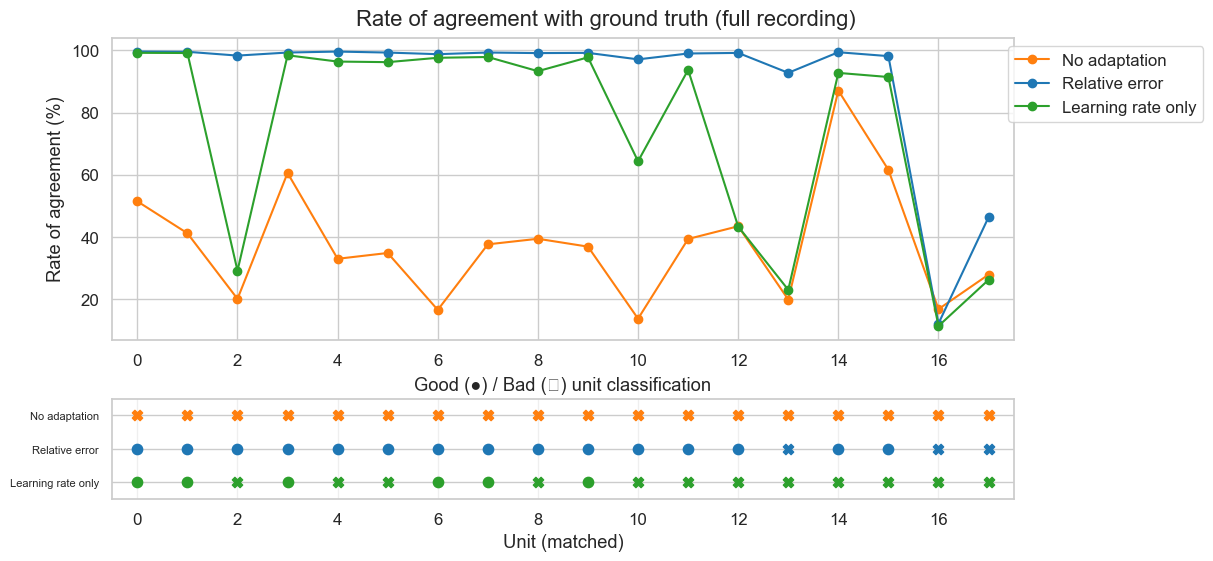

In [25]:
roa_no_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_no['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_re_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_re['spikes'].numpy(), fs=fs, tol_spike_ms=2)
roa_lo_full, _, _ = rate_of_agreement_paired(
    sim_spikes, out_lo['spikes'].numpy(), fs=fs, tol_spike_ms=2)

unit_ids = pair_arr[:, 1]
n_pairs  = len(unit_ids)
x        = np.arange(n_pairs)

print(f'RoA full | No adaptation:      {roa_no_full.mean()*100:.2f} ± {roa_no_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_no_full)*100:.2f}%)')
print(f'RoA full | Relative error:     {roa_re_full.mean()*100:.2f} ± {roa_re_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_re_full)*100:.2f}%)')
print(f'RoA full | Learning rate only: {roa_lo_full.mean()*100:.2f} ± {roa_lo_full.std()*100:.2f}%  '
      f'(med: {np.median(roa_lo_full)*100:.2f}%)')

good_lookup = {
    label: df_all[df_all['condition'] == label].set_index('unit')['good']
    for label in cond_labels
}

fig, (ax_roa, ax_good) = plt.subplots(
    2, 1, figsize=(12, 5.5), layout='constrained',
    gridspec_kw={'height_ratios': [3, 1]},
)
ax_roa.plot(x, roa_no_full * 100, marker='o', label='No adaptation',      color=cond_colors['No adaptation'])
ax_roa.plot(x, roa_re_full * 100, marker='o', label='Relative error',     color=cond_colors['Relative error'])
ax_roa.plot(x, roa_lo_full * 100, marker='o', label='Learning rate only', color=cond_colors['Learning rate only'])
ax_roa.set(ylabel='Rate of agreement (%)', xlim=(-0.5, n_pairs - 0.5))
ax_roa.legend(loc='upper right', bbox_to_anchor=(1.22, 1))

y_pos = {'No adaptation': 2, 'Relative error': 1, 'Learning rate only': 0}
for label in cond_labels:
    for i, uid in enumerate(unit_ids):
        is_good = bool(good_lookup[label].get(uid, False))
        ax_good.scatter(i, y_pos[label],
                        color=cond_colors[label],
                        marker='o' if is_good else 'X',
                        s=55, zorder=3)

ax_good.set_yticks(list(y_pos.values()))
ax_good.set_yticklabels(list(y_pos.keys()), fontsize=8)
ax_good.set(xlabel='Unit (matched)', xlim=(-0.5, n_pairs - 0.5),
            title='Good (●) / Bad (✗) unit classification',
            ylim=(-0.5, len(y_pos) - 0.5))
ax_good.grid(axis='x', alpha=0.3)
plt.suptitle('Rate of agreement with ground truth (full recording)')
plt.show()


In [26]:
# Save per-unit RoA for the comparison notebook
roa_summary = {
    'unit_ids': unit_ids.tolist(),
    'roa_no':   roa_no_full.tolist(),
    'roa_re':   roa_re_full.tolist(),
    'roa_lo':   roa_lo_full.tolist(),
}
with open(RESULTS_DIR / 'roa_summary.json', 'w') as f:
    json.dump(roa_summary, f, indent=2)

# Save quality metrics DataFrame
df_all.to_csv(RESULTS_DIR / 'quality_metrics.csv', index=False)
print(f'Saved RoA summary and quality metrics → {RESULTS_DIR}')


Saved RoA summary and quality metrics → ..\data\example\opt_results\kl_to_cal_lr_alone_calibration
